# Real Gradient Flow Visualization (TensorFlow)

- Train MNIST model

- Intercept gradients using GradientTape

- Measure gradient size layer-by-layer

- Plot gradient flow

**Import Library**

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

**Load MNIST**

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten Images
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


# Build Deep Network

I intentionally make it deep so gradient problems can appear

In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation='sigmoid', input_shape=(784,)),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [7]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

# Capture Gradients

In [8]:
# Take a small batch
x_batch = x_train[:256]
y_batch = y_train[:256]

with tf.GradientTape() as tape:
    predictions = model(x_batch, training=True)
    loss = loss_fn(y_batch, predictions)

# Compute Gradients
gradients = tape.gradient(loss, model.trainable_variables)

# Measure Gradient Magnitude Per Layer

In [9]:
layer_grads = []

for grad in gradients:
    if grad is not None:
        layer_grads.append(tf.reduce_mean(tf.abs(grad)).numpy())

In [10]:
for i, g in enumerate(layer_grads):
    print(f"Layer {i+1} gradient magnitude: {g:.8f}")

Layer 1 gradient magnitude: 0.00000202
Layer 2 gradient magnitude: 0.00001191
Layer 3 gradient magnitude: 0.00002820
Layer 4 gradient magnitude: 0.00005568
Layer 5 gradient magnitude: 0.00013792
Layer 6 gradient magnitude: 0.00027280
Layer 7 gradient magnitude: 0.00051536
Layer 8 gradient magnitude: 0.00104549
Layer 9 gradient magnitude: 0.00242925
Layer 10 gradient magnitude: 0.00484380
Layer 11 gradient magnitude: 0.03362425
Layer 12 gradient magnitude: 0.06657746


### Plot Gradient Flow

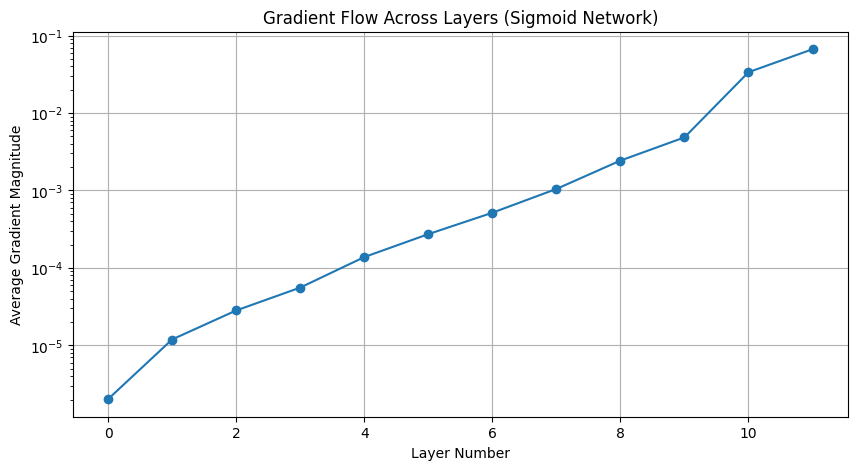

In [11]:
plt.figure(figsize=(10,5))
plt.plot(layer_grads, marker='o')
plt.title("Gradient Flow Across Layers (Sigmoid Network)")
plt.xlabel("Layer Number")
plt.ylabel("Average Gradient Magnitude")
plt.yscale("log")
plt.grid()
plt.show()

> First layers → extremely tiny gradient
> Last layers → larger gradient

This is vanishing gradient in real neural network

Earlier layers basically learn nothing

Note: Now Change ONE Line

Change activation:
>> activation='relu'

*Run again, You’ll see:*

• Gradients become stable

• Early layers start learning

**This visually proves:**

Why deep learning started working only after ReLU (2012 AlexNet).

| Activation | Expected Result          |
| ---------- | ------------------------ |
| Sigmoid    | vanishing                |
| Tanh       | partial vanishing        |
| ReLU       | stable                   |
| Leaky ReLU | best                     |
| GELU       | transformer-style stable |


**This Projectcabout**

Backpropagation

Jacobians

Optimization difficulty

Why architectures evolved
